---
# **Supervised Learning** - Handling SensorStats.csv
---

In [1]:
import pandas as pd

df = pd.read_csv('data/SensorStats.csv')
df.head()

,Asset Class,VOC Emissions,Acoustic / Vibration,CPU Utilization,Mechanical Load,Axis Elevation / Altitude,Actuator Torque,Thermal Load,Remote Override Flag,Airborne Status,Compromise Risk Index
0,drone,360.0,53.0,33.370,349.2,315.689836,73.5,33.077273,0,1,0.0
1,agv_units,303.0,43.5,130.480,355.5,323.612212,82.5,4.931818,0,1,0.0
2,plc_controller,66.0,14.0,150.400,116.1,207.695037,19.0,26.529545,0,0,0.0
3,agv_units,327.0,28.5,155.380,370.2,316.605962,74.5,9.036364,0,1,0.0
4,agv_units,321.0,49.0,166.585,193.8,227.480995,68.0,5.713636,0,0,0.0


### EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Asset Class                10000 non-null  object 
 1   VOC Emissions              9975 non-null   float64
 2   Acoustic / Vibration       9970 non-null   float64
 3   CPU Utilization            9972 non-null   float64
 4   Mechanical Load            9966 non-null   float64
 5   Axis Elevation / Altitude  9966 non-null   float64
 6   Actuator Torque            9972 non-null   float64
 7   Thermal Load               9959 non-null   float64
 8   Remote Override Flag       10000 non-null  int64  
 9   Airborne Status            10000 non-null  int64  
 10  Compromise Risk Index      10000 non-null  float64
dtypes: float64(8), int64(2), object(1)
memory usage: 859.5+ KB


**Note -**  "Remote Override Flag" and "Airborne Status" are left out as they are binary.

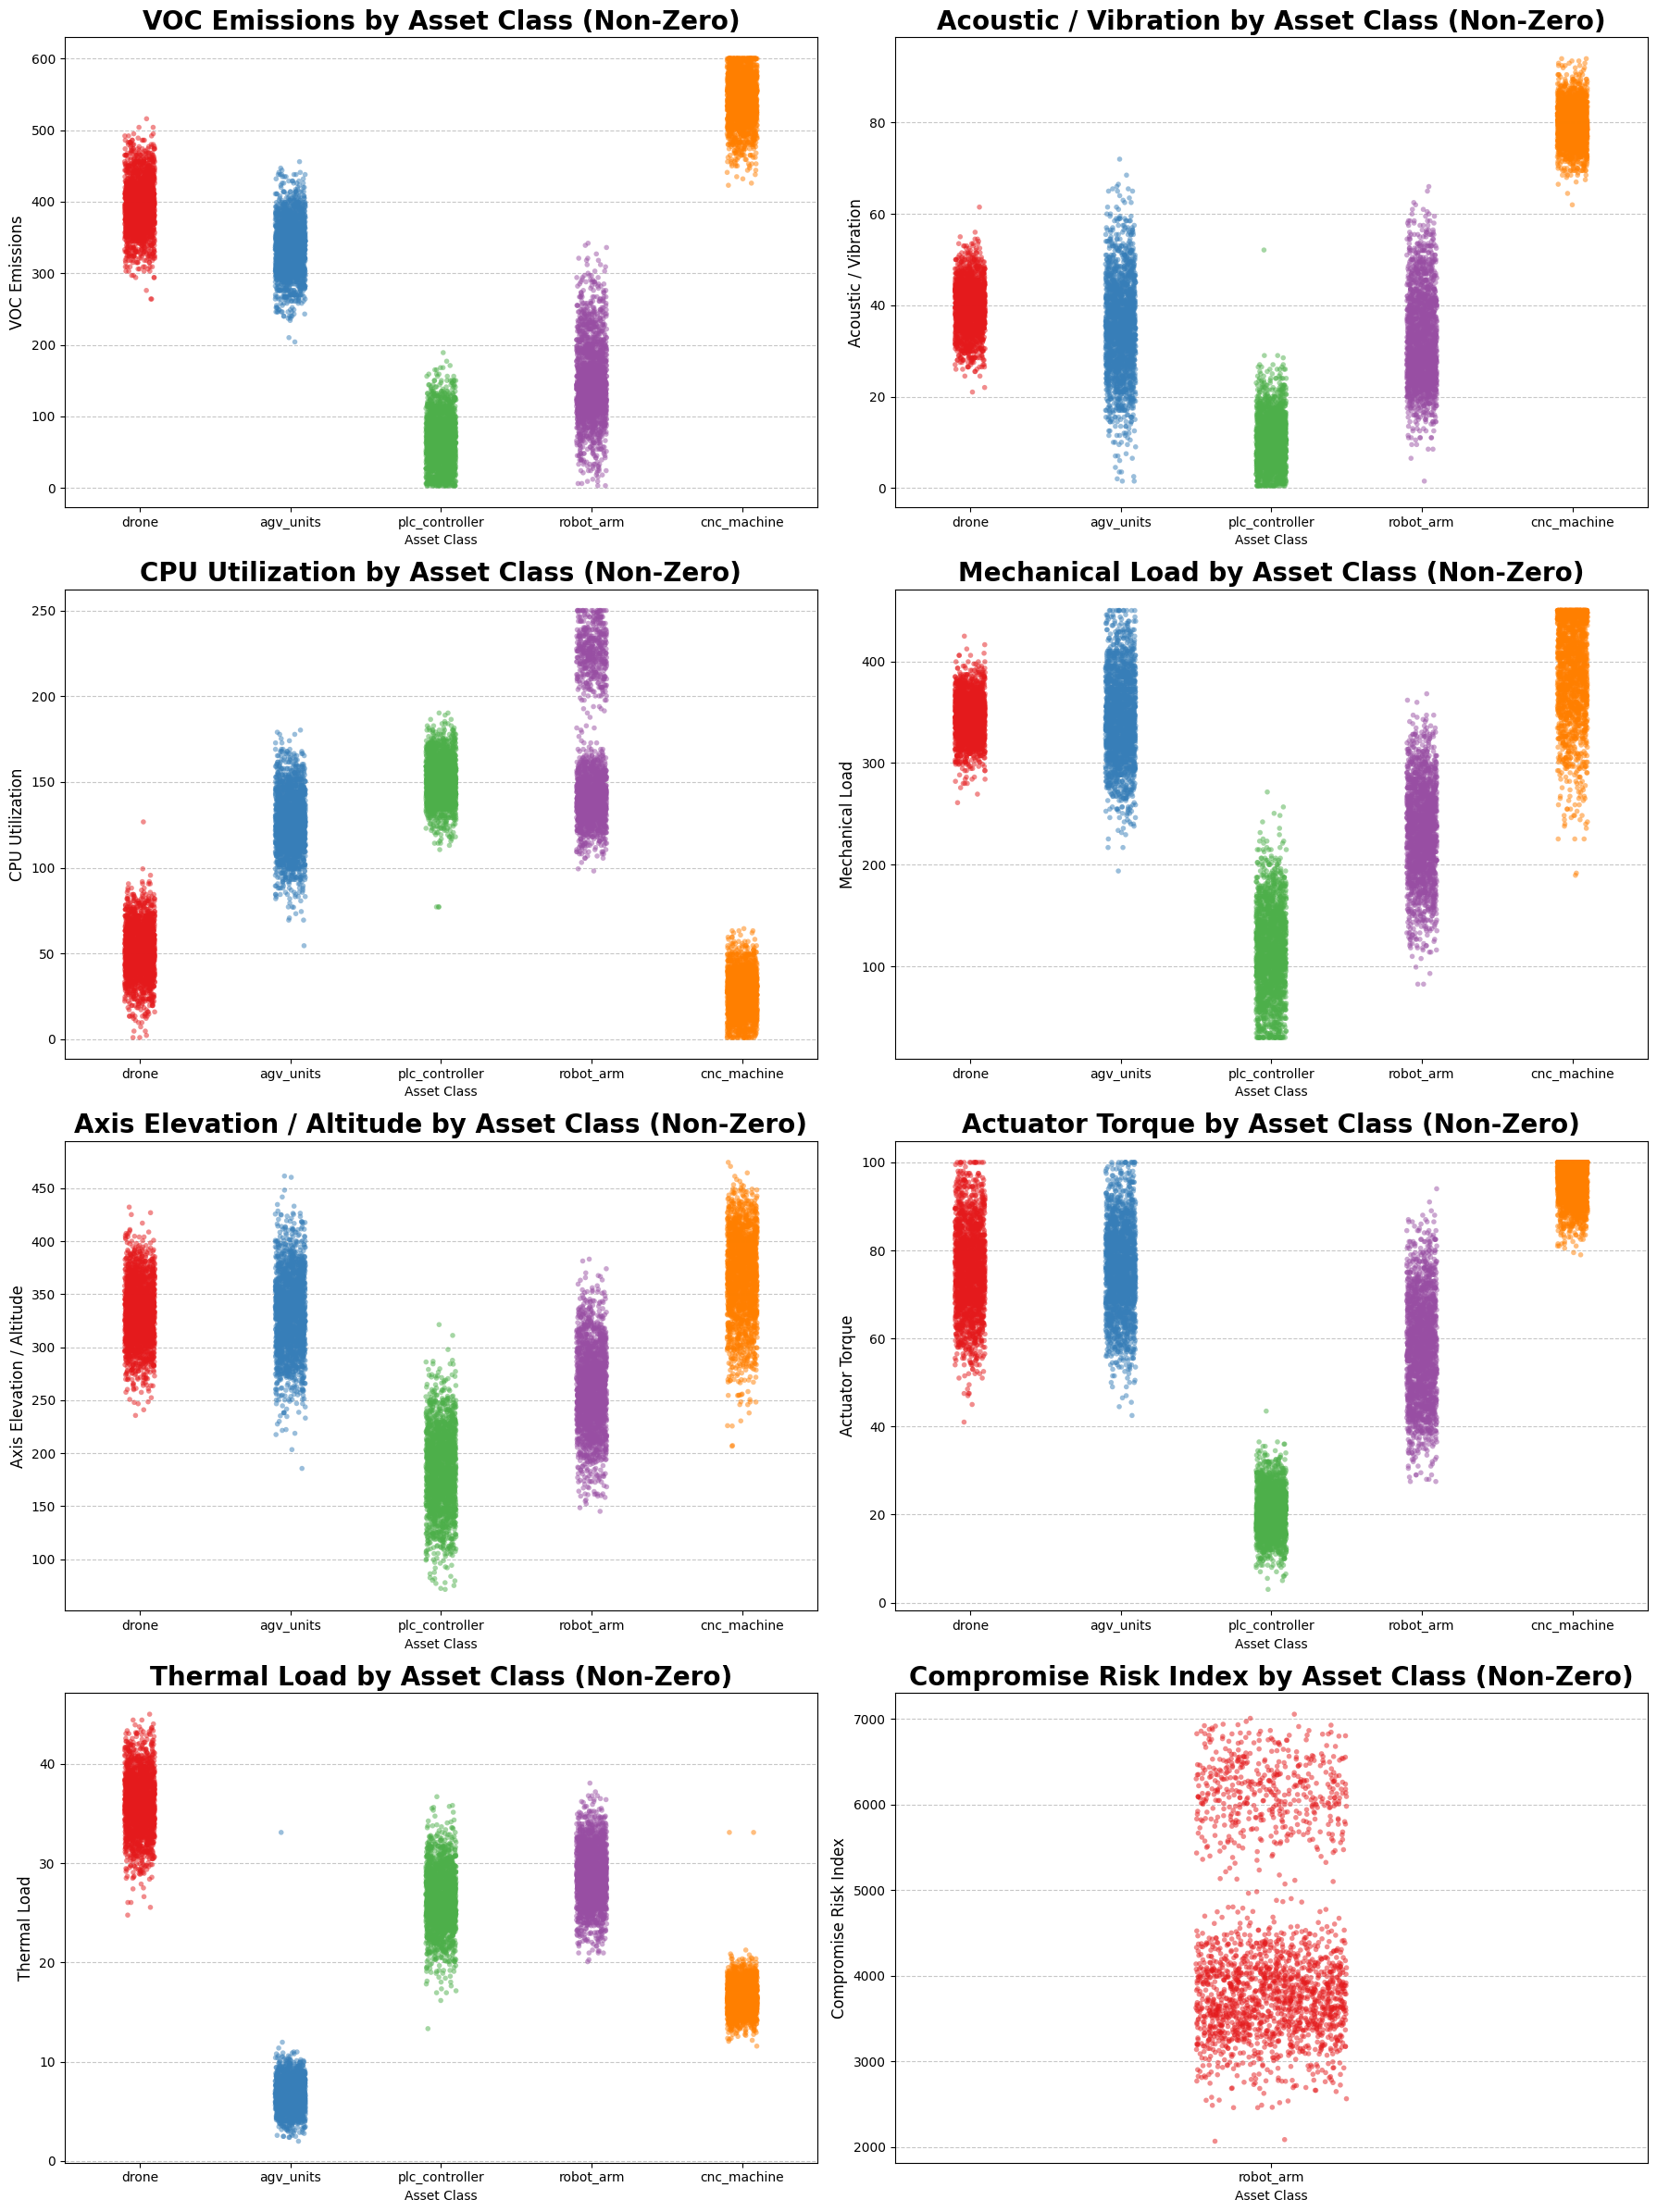

In [3]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Selecting main features
features_to_plot = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 
    'Mechanical Load', 'Axis Elevation / Altitude', 'Actuator Torque', 
    'Thermal Load', 'Compromise Risk Index'
]

# 4. Set up the plotting grid (4 rows, 2 columns)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

# 5. Loop through each feature, filter out zeros, and plot
for i, feature in enumerate(features_to_plot):
    # Filter: Keep only rows where THIS specific feature is greater than 0
    # We also drop NaNs just for the plot so seaborn doesn't complain
    active_data = df[df[feature] > 0].dropna(subset=[feature])
    
    sns.stripplot(
        data=active_data, 
        x='Asset Class', 
        y=feature, 
        ax=axes[i],
        jitter=True, 
        alpha=0.5,
        palette='Set1',
        size=4
    )
    
    axes[i].set_title(f'{feature} by Asset Class (Non-Zero)', fontsize=20, fontweight='bold')
    axes[i].set_ylabel(feature, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [4]:
# Finding about Remote Override Flag and Airborne Status
def flag_details(df, cols):

    stats = df.groupby("Asset Class")[cols].agg(["sum", "count"])
    return stats.apply(
        lambda row: f"{int(row['sum'])} / {int(row['count'])}",
        axis=1
    )
 
print("\nRemote Override Flag")
print(flag_details(df, "Remote Override Flag"))
 
print("\nAirborne Status")
print(flag_details(df, "Airborne Status"))


Remote Override Flag
Asset Class
agv_units           0 / 2000
cnc_machine         0 / 2000
drone               0 / 2000
plc_controller      0 / 2000
robot_arm         500 / 2000
dtype: object

Airborne Status
Asset Class
agv_units          961 / 2000
cnc_machine          0 / 2000
drone             2000 / 2000
plc_controller       0 / 2000
robot_arm            0 / 2000
dtype: object


In [5]:
# Finding how many Compromise Risk Index which are non zeros and Override Active ofr robot_arm
arm_df = df[df['Asset Class'] == 'robot_arm']

print(f"\nTotal Robotic Arms        : {len(arm_df)}")
print(f"Override Flag Active      : {len(arm_df[arm_df['Remote Override Flag'] == 1])}")
print(f"Compromise Risk Index > 0 : {len(arm_df[arm_df['Compromise Risk Index'] > 0])}")

arms_both = len(arm_df[
    (arm_df['Remote Override Flag'] == 1) &
    (arm_df['Compromise Risk Index'] > 0)
])
print(f"Override Active AND Exposed: {arms_both} ")


Total Robotic Arms        : 2000
Override Flag Active      : 500
Compromise Risk Index > 0 : 2000
Override Active AND Exposed: 500 


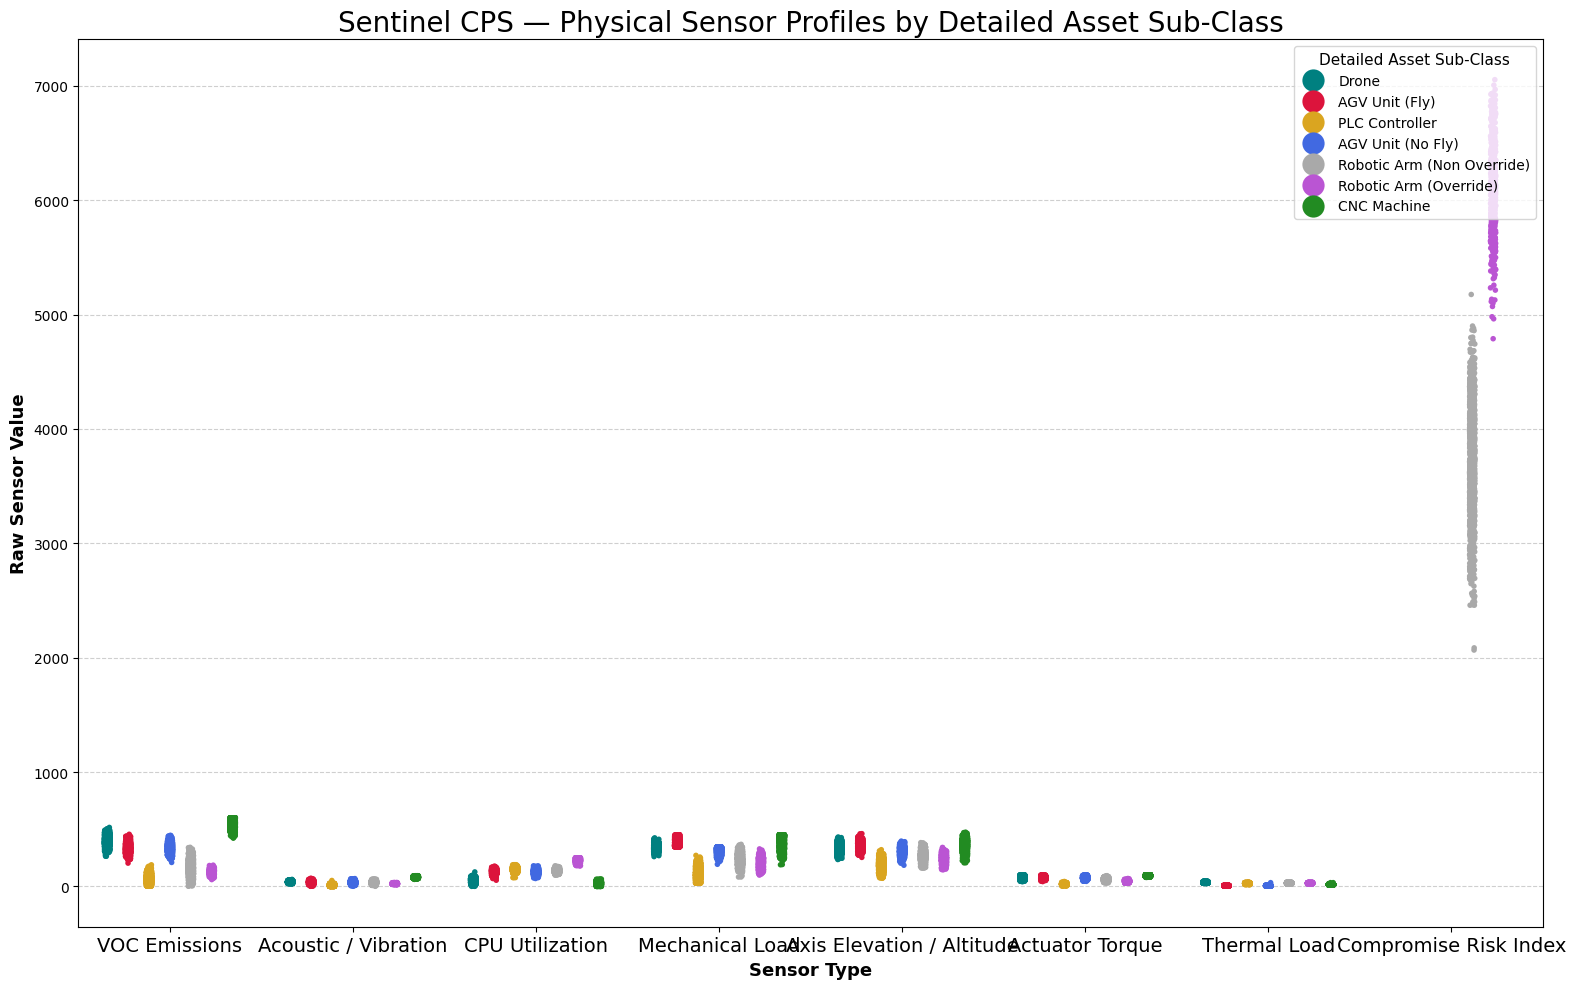

In [ ]:
# Plotting All to single Graphs

# As we can see Robot Arms and AGV are divided based on Remote Override Flag and Airborne Status respectively
# So we categories to 7 category
def categorize_detailed(row):
    asset = row["Asset Class"]
    if asset == "robot_arm":
        return "Robotic Arm (Override)" if row["Remote Override Flag"] == 1 else "Robotic Arm (Non Override)"
    elif asset == "agv_units":
        return "AGV Unit (Fly)" if row["Airborne Status"] == 1 else "AGV Unit (No Fly)"
    elif asset == "cnc_machine":
        return "CNC Machine"
    elif asset == "plc_controller":
        return "PLC Controller"
    elif asset == "drone":
        return "Drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])

# Setting up a custom color palette for all 7 categories
custom_palette = {
    'Robotic Arm (Override)': 'mediumorchid',
    'Robotic Arm (Non Override)': 'darkgray',
    'AGV Unit (Fly)': 'crimson',
    'AGV Unit (No Fly)': 'royalblue',
    'CNC Machine': 'forestgreen',
    'PLC Controller': 'goldenrod',
    'Drone': 'teal'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class",
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

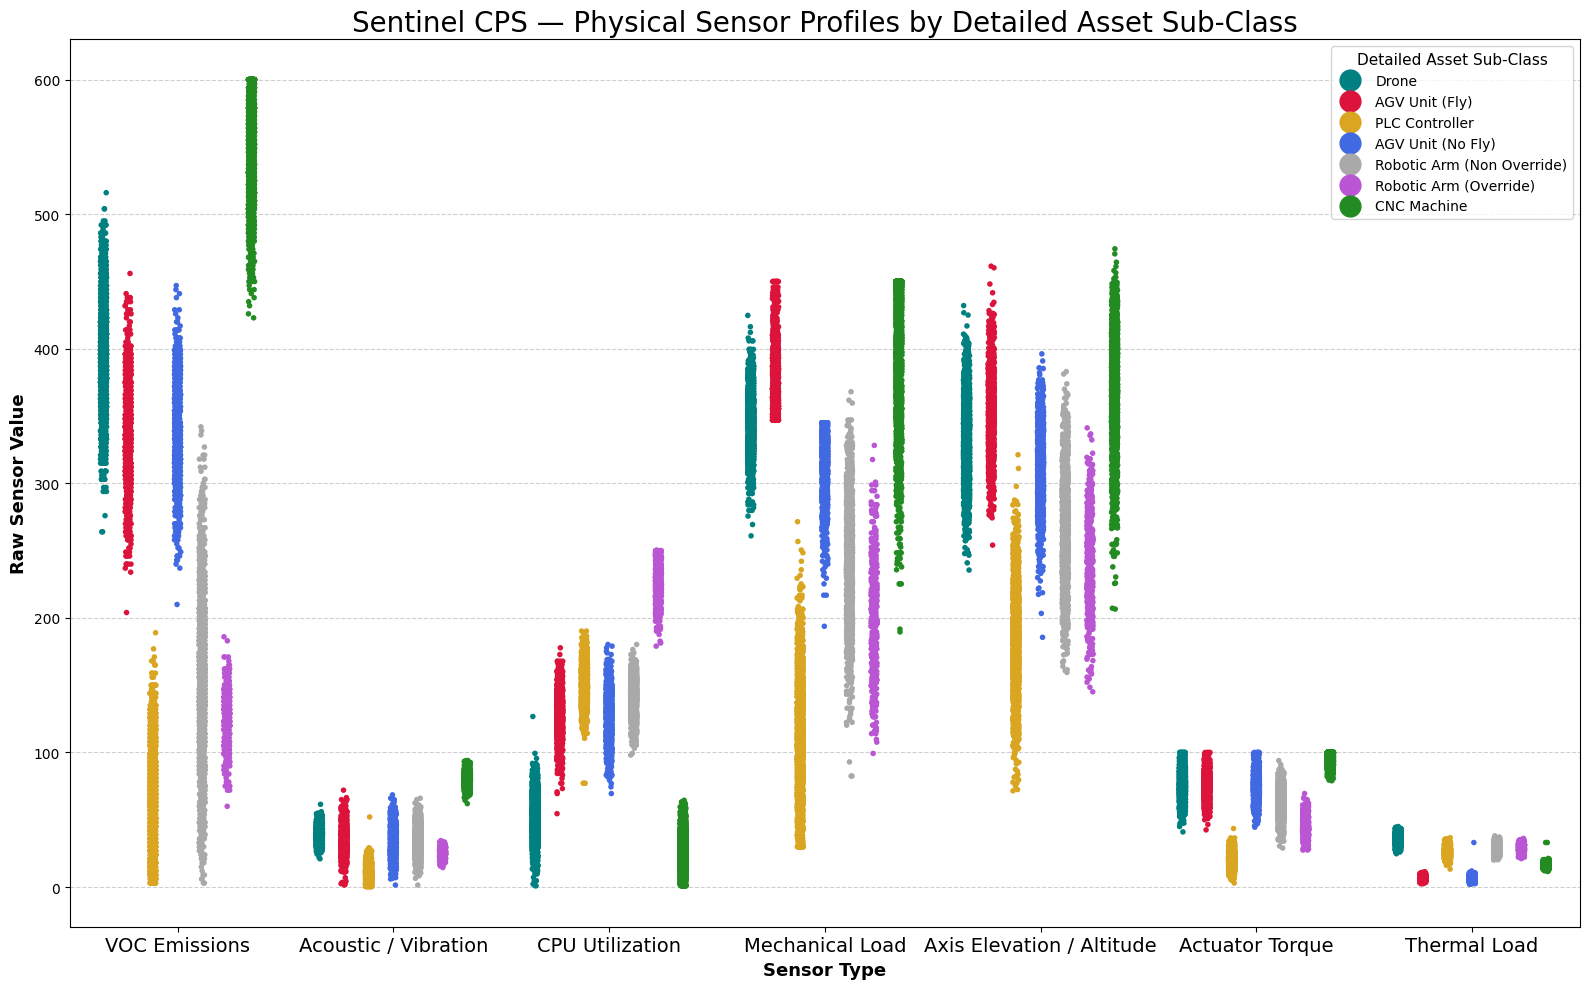

In [ ]:
# Plotting All to single Graphs except Compromise Risk Index

# 2. Define the continuous features (EXCLUDING Compromise Risk Index)
features_to_plot = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 'Mechanical Load',
    'Axis Elevation / Altitude', 'Actuator Torque', 'Thermal Load'
]

# As we can see Robot Arms and AGV are divided based on Remote Override Flag and Airborne Status respectively
# So we categories to 7 category
def categorize_detailed(row):
    asset = row["Asset Class"]
    if asset == "robot_arm":
        return "Robotic Arm (Override)" if row["Remote Override Flag"] == 1 else "Robotic Arm (Non Override)"
    elif asset == "agv_units":
        return "AGV Unit (Fly)" if row["Airborne Status"] == 1 else "AGV Unit (No Fly)"
    elif asset == "cnc_machine":
        return "CNC Machine"
    elif asset == "plc_controller":
        return "PLC Controller"
    elif asset == "drone":
        return "Drone"
    return "Unknown"

df['Detailed Asset Class'] = df.apply(categorize_detailed, axis=1)

# Reshaping the data for seaborn graph
melted_df = pd.melt(
    df, 
    id_vars=['Detailed Asset Class'], 
    value_vars=features_to_plot,             
    var_name='Sensor Type',
    value_name='Sensor Value'
)

# Removing  NaN
active_df = melted_df[melted_df["Sensor Value"] > 0].dropna(subset=["Sensor Value"])
# Setting up a custom color palette for all 7 categories
custom_palette = {
    'Robotic Arm (Override)': 'mediumorchid',
    'Robotic Arm (Non Override)': 'darkgray',
    'AGV Unit (Fly)': 'crimson',
    'AGV Unit (No Fly)': 'royalblue',
    'CNC Machine': 'forestgreen',
    'PLC Controller': 'goldenrod',
    'Drone': 'teal'
}
 
# Building the plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.stripplot(
    data=active_df,
    x="Sensor Type",
    y="Sensor Value",
    hue="Detailed Asset Class", # <--- Fixed this line
    jitter=True,
    palette=custom_palette,
    size=4,
    dodge=True,
    ax=ax,
)
 
ax.set_title(
    "Sentinel CPS — Physical Sensor Profiles by Detailed Asset Sub-Class",
    fontsize=20
)
ax.set_xlabel("Sensor Type",   fontsize=13, fontweight="bold")
ax.set_ylabel("Raw Sensor Value", fontsize=13, fontweight="bold")
ax.tick_params(axis="x",labelsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(
    title="Detailed Asset Sub-Class",
    title_fontsize=11,
    fontsize=10,
    markerscale=4,
    loc="upper right",
)
 
plt.tight_layout()
plt.savefig("sentinel_sensor_profiles.png", dpi=150)
plt.show()

### **Observation**
1. Dataset Composition**
    - 10,000 total entries across 5 asset classes, 2,000 per class.
    - Continuous telemetry features contain minor missing values (range: 9,959–9,975 non-null out of 10,000). Binary columns (Remote Override Flag, Airborne Status) and Compromise Risk Index are complete with 10,000 non-null entries.
    - Missing value strategy: median imputation to be applied prior to model training.
2. Airborne Status Distribution
    - All 2,000 Inspection Drone entries have Airborne Status = 1.
    - AGV Unit entries are split: 961 with Airborne Status = 1, 1,039 with Airborne Status = 0.
    - AGV Unit which can fly have more mechanical load than non flying AGV, maybe due to battery weight. It looks like above 350.
    - All remaining asset classes (Robotic Arm, CNC Machine, PLC Controller) have Airborne Status = 0 throughout.
3. Compromise Risk Index
    - Non-zero Compromise Risk Index values are present exclusively in the Robotic Arm class. All other asset classes register 0.00 across all 8,000 entries.
    - Within the 2000 Robotic Arm entries: all 2000 carry a Compromise Risk Index > 0, forming two distinct value bands. 
    - The upper band (approx. 5,000–7,000) corresponds exactly to the 500 entries where Remote Override Flag = 1. The lower band corresponds to the remaining 1,500 entries where Remote Override Flag = 0.


### **Conclusion**
We must strictly exclude the Remote Override Flag and Airborne Status from the feature set used to train the Supervised Learning (SL) models mainly due to 2 reasons:
* **Prevention of Target Leakage:** Including risk or override flags acts as an "answer key." This causes artificial 100% accuracy and prevents the model from learning true physical anomaly signatures.
* **Preservation of Ground Truth:** Withholding these deterministic columns creates an independent, uncorrupted validation layer. We can use these to verfy later.

## Model Selection for Supervised Learning

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

features = [
    'VOC Emissions', 'Acoustic / Vibration', 'CPU Utilization', 'Mechanical Load',
    'Axis Elevation / Altitude', 'Actuator Torque', 'Thermal Load', 'Compromise Risk Index'
]

x = df[features]
y = df['Asset Class'] # Updated to use the industrial mapped column

# Replacing missing sensor packets  with 0
x = x.fillna(0)

# Train-Test Split (80/20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 6. Initializing the Supervised Learning Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and Evaluate Each Model
results = []

for name, model in models.items():
    start_time = time.perf_counter()
    
    # Train
    model.fit(x_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(x_test_scaled)
    elapsed = time.perf_counter() - start_time

    # Calculate Metrics (Macro average computes the metric independently for each asset class)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Time (s)": elapsed
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("SUPERVISED LEARNING LEADERBOARD")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

SUPERVISED LEARNING LEADERBOARD
              Model  Accuracy  Precision  Recall  Time (s)
      Random Forest    0.9995     0.9995  0.9995    0.4489
  Gradient Boosting    0.9990     0.9990  0.9990    4.6433
   SVM (RBF Kernel)    0.9975     0.9975  0.9975    0.0514
      Decision Tree    0.9965     0.9965  0.9965    0.0290
K-Nearest Neighbors    0.9960     0.9960  0.9960    0.0841
Logistic Regression    0.9930     0.9930  0.9930    0.0631


#### **We are selecting Random Forest and SVM (RBF Kernel)** Reason Explained in Report

---
# **Unsupervised Learning** - Image Handling
---

In [9]:
import os
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import Birch
from sklearn.mixture import GaussianMixture
from src.usl_feature_extractor import get_feature
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score

In [10]:
# EVALUTION FUNCTION
def get_clustering_metrics(true_labels, raw_clusters, method_name):
    """Calculates standard unsupervised metrics from raw cluster assignments."""
    return {
        "Method": method_name,
        "ARI": adjusted_rand_score(true_labels, raw_clusters),
        "NMI": normalized_mutual_info_score(true_labels, raw_clusters),
        "Homogeneity": homogeneity_score(true_labels, raw_clusters)
    }
    return pd.concat([df, row], ignore_index=True)

# Maps arbitrary cluster numbers to the majority Asset Class
def map_clusters_to_truth(true_labels, cluster_labels):
    mapped_labels = np.empty_like(cluster_labels, dtype=object)
    for c in np.unique(cluster_labels):
        # Find all images assigned to this cluster
        mask = (cluster_labels == c)
        # What is the most common actual asset in this cluster?
        if np.any(mask):
            majority_label = pd.Series(true_labels[mask]).mode()[0]
            mapped_labels[mask] = majority_label
    return mapped_labels

### Different USL model

In [11]:
def seed_everything(seed=42):
    # Standard Python/Library seeds
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Call this ONCE at the very top of your notebook
seed_everything(42)

In [12]:
# Getting Features from src file.
df_pca = get_feature(base_dir="data/fantasy_dataset", use_pca=True)
df_umap = get_feature(base_dir="data/fantasy_dataset", use_pca=False)
print(df_pca.head())
print(df_umap.head())


FEATURE PIPELINE INITIATED
Got 8018 images in 'data/fantasy_dataset'
Preparing Images for CAE Inference
  -> CAE Features Extracted: (8018, 128)
  -> CV Extraction for 8018 images


CV feature Extractor: 100%|██████████| 8018/8018 [00:15<00:00, 529.33it/s] 



Applying PCA compression

Pipeline complete.
Final PCA Fused Tensor Shape: (8018, 62)

FEATURE PIPELINE INITIATED
Got 8018 images in 'data/fantasy_dataset'
Preparing Images for CAE Inference
  -> CAE Features Extracted: (8018, 128)
  -> CV Extraction for 8018 images


CV feature Extractor: 100%|██████████| 8018/8018 [00:15<00:00, 524.88it/s] 



Applying UMAP compression

Pipeline complete.
Final UMAP Fused Tensor Shape: (8018, 62)
                image_name     Asset Class  \
0  plc_controller_F165.png  plc_controller   
1  plc_controller_E283.png  plc_controller   
2  plc_controller_E158.png  plc_controller   
3  plc_controller_A090.png  plc_controller   
4  plc_controller_F043.png  plc_controller   

                                      fused_features  
0  [0.03537927287100451, 0.0019172099881141125, 0...  
1  [-1.0152081809738998, 0.2623933722055891, -0.1...  
2  [-0.7051694983608883, -0.07803836169853687, 0....  
3  [-0.050216599626054195, -1.3363743504782704, -...  
4  [-0.9620582329891139, 0.00759033675710734, -0....  
                image_name     Asset Class  \
0  plc_controller_F165.png  plc_controller   
1  plc_controller_E283.png  plc_controller   
2  plc_controller_E158.png  plc_controller   
3  plc_controller_A090.png  plc_controller   
4  plc_controller_F043.png  plc_controller   

                           

In [13]:
# Extract Data for Clustering
X_pca = np.array(df_pca['fused_features'].tolist())
X_umap = np.array(df_umap['fused_features'].tolist())
true_labels = df_pca['Asset Class'].values
unique_classes = np.unique(true_labels)
n_clusters = len(unique_classes)

In [14]:
# RUNNING THE MODELS
def run_gmm_analysis(x):
    gmm = GaussianMixture(n_components=5, covariance_type='spherical', random_state=42, n_init=10)
    gmm.fit(x)
    probs = gmm.predict_proba(x)
    clusters = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    return clusters, confidences, probs

def run_birch_analysis(x):
    # BIRCH is a hard clusterer, so it only returns cluster labels (no probabilities)
    birch = Birch(n_clusters=5)
    clusters = birch.fit_predict(x)
    return clusters

print("\nProcessing GMM and BIRCH on both reducers...")
# GMM
clusters_gmm_pca, conf_gmm_pca, p_mat_pca = run_gmm_analysis(X_pca)
clusters_gmm_umap, conf_gmm_umap, p_mat_umap = run_gmm_analysis(X_umap)
# BIRCH
clusters_birch_pca = run_birch_analysis(X_pca)
clusters_birch_umap = run_birch_analysis(X_umap)


Processing GMM and BIRCH on both reducers...


In [15]:
metrics_gmm_pca = get_clustering_metrics(true_labels, clusters_gmm_pca, "GMM + PCA (k=5)")
metrics_gmm_umap = get_clustering_metrics(true_labels, clusters_gmm_umap, "GMM + UMAP (k=5)")
metrics_birch_pca = get_clustering_metrics(true_labels, clusters_birch_pca, "BIRCH + PCA (k=5)")
metrics_birch_umap = get_clustering_metrics(true_labels, clusters_birch_umap, "BIRCH + UMAP (k=5)")

results_df = pd.DataFrame([metrics_gmm_pca, metrics_gmm_umap, metrics_birch_pca, metrics_birch_umap])
print("\n--- Sentinel-CPS: Clustering Evaluation Metrics ---")
display(results_df.round(4))


--- Sentinel-CPS: Clustering Evaluation Metrics ---


,Method,ARI,NMI,Homogeneity
0,GMM + PCA (k=5),0.2873,0.4600,0.4549
1,GMM + UMAP (k=5),0.2521,0.3834,0.3773
2,BIRCH + PCA (k=5),0.4938,0.6093,0.6200
3,BIRCH + UMAP (k=5),0.2820,0.4252,0.4089


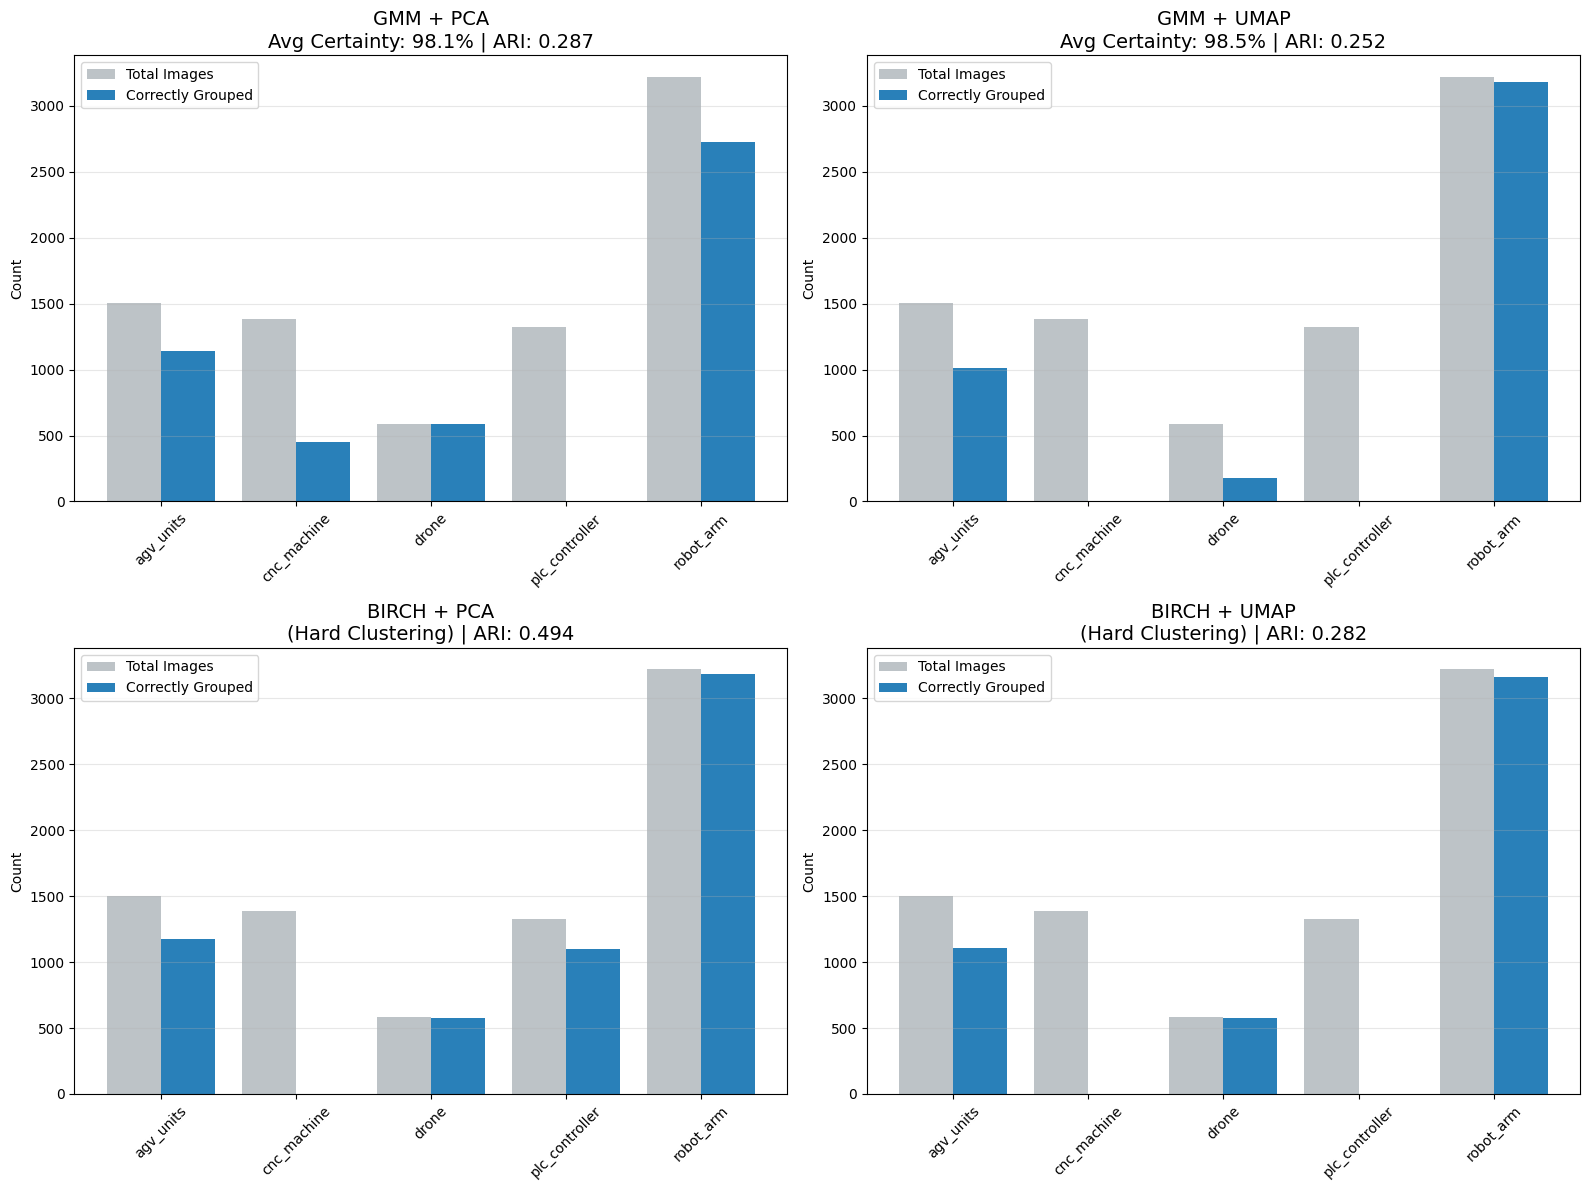

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Flattens the 2x2 matrix into a 1D array for easy iteration

def plot_clustering_results(ax, clusters, conf, title):
    # Mapping clusters to Asset Names
    mapped_preds = np.empty_like(clusters, dtype=object)
    for c in np.unique(clusters):
        mask = (clusters == c)
        if np.any(mask):
            majority = pd.Series(true_labels[mask]).mode()[0]
            mapped_preds[mask] = majority
            
    # Calculate Metrics
    ari = adjusted_rand_score(true_labels, clusters)
    
    # Plot bars
    x_indices = np.arange(len(unique_classes))
    totals = [np.sum(true_labels == cls) for cls in unique_classes]
    corrects = [np.sum((true_labels == cls) & (mapped_preds == cls)) for cls in unique_classes]
    
    ax.bar(x_indices - 0.2, totals, width=0.4, label='Total Images', color='#bdc3c7')
    ax.bar(x_indices + 0.2, corrects, width=0.4, label='Correctly Grouped', color='#2980b9')
    
    # Handle titles dynamically (since BIRCH has no confidences)
    if conf is not None:
        avg_conf = np.mean(conf) * 100
        ax.set_title(f"{title}\nAvg Certainty: {avg_conf:.1f}% | ARI: {ari:.3f}", fontsize=14)
    else:
        ax.set_title(f"{title}\n(Hard Clustering) | ARI: {ari:.3f}", fontsize=14)
        
    ax.set_xticks(x_indices)
    ax.set_xticklabels(unique_classes, rotation=45)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plot_clustering_results(axes[0], clusters_gmm_pca, conf_gmm_pca, "GMM + PCA")
plot_clustering_results(axes[1], clusters_gmm_umap, conf_gmm_umap, "GMM + UMAP")
plot_clustering_results(axes[2], clusters_birch_pca, None, "BIRCH + PCA")
plot_clustering_results(axes[3], clusters_birch_umap, None, "BIRCH + UMAP")

plt.tight_layout()
plt.show()

In [17]:
low_conf_mask = conf_gmm_pca < 0.70
print(f"\nFound {np.sum(low_conf_mask)} images with low classification confidence (GMM+PCA).")
if np.sum(low_conf_mask) > 0:
    print("These are potential 'OOD' (Out of Distribution) anomalies for your report.")


Found 168 images with low classification confidence (GMM+PCA).
These are potential 'OOD' (Out of Distribution) anomalies for your report.


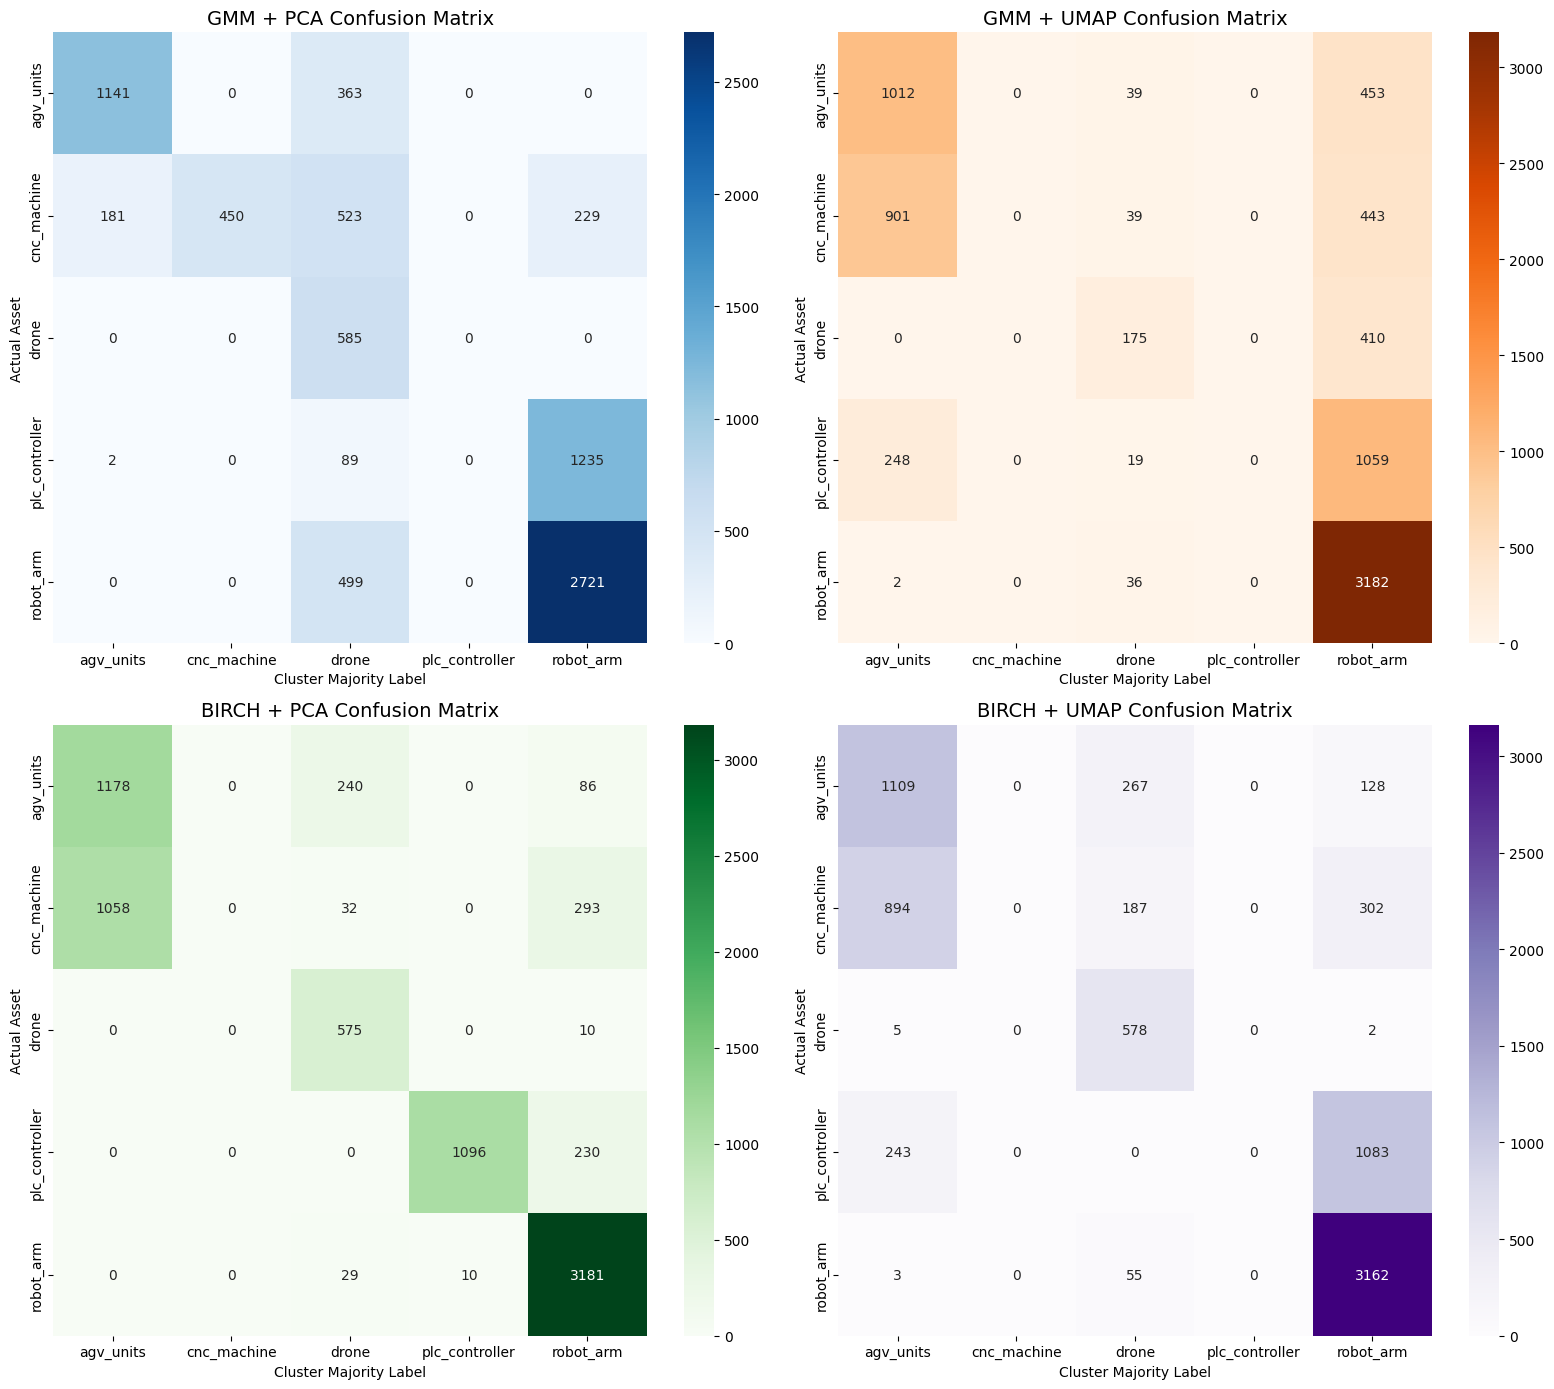

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

pred_labels_gmm_pca = map_clusters_to_truth(true_labels, clusters_gmm_pca)
pred_labels_gmm_umap = map_clusters_to_truth(true_labels, clusters_gmm_umap)
pred_labels_birch_pca = map_clusters_to_truth(true_labels, clusters_birch_pca)
pred_labels_birch_umap = map_clusters_to_truth(true_labels, clusters_birch_umap)

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(16, 14))
axes_cm = axes_cm.flatten()

def plot_cm(ax, preds, title, cmap):
    cm = confusion_matrix(true_labels, preds, labels=unique_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=unique_classes, yticklabels=unique_classes, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Actual Asset')
    ax.set_xlabel('Cluster Majority Label')

# Plot all 4 matrices with slightly different color maps to distinguish methods
plot_cm(axes_cm[0], pred_labels_gmm_pca, 'GMM + PCA Confusion Matrix', 'Blues')
plot_cm(axes_cm[1], pred_labels_gmm_umap, 'GMM + UMAP Confusion Matrix', 'Oranges')
plot_cm(axes_cm[2], pred_labels_birch_pca, 'BIRCH + PCA Confusion Matrix', 'Greens')
plot_cm(axes_cm[3], pred_labels_birch_umap, 'BIRCH + UMAP Confusion Matrix', 'Purples')

plt.tight_layout()
plt.show()

Executing Deep Embedding Clustering on: CUDA
Training Hybrid DEC (BIRCH Base): 15 Epochs CE Warm-Up -> 65 Epochs KL Self-Supervised...
Epoch [10/80] | Warm-Up (CE) | Train Loss: 0.0326 | Val Loss: 0.0356
Epoch [20/80] | Self-Supervised (KL) | Train Loss: 0.0034 | Val Loss: 0.0037
Epoch [30/80] | Self-Supervised (KL) | Train Loss: 0.0015 | Val Loss: 0.0019
Epoch [40/80] | Self-Supervised (KL) | Train Loss: 0.0007 | Val Loss: 0.0012
Epoch [50/80] | Self-Supervised (KL) | Train Loss: 0.0003 | Val Loss: 0.0010
Epoch [60/80] | Self-Supervised (KL) | Train Loss: 0.0002 | Val Loss: 0.0008
Epoch [70/80] | Self-Supervised (KL) | Train Loss: 0.0001 | Val Loss: 0.0007
Epoch [80/80] | Self-Supervised (KL) | Train Loss: 0.0001 | Val Loss: 0.0006


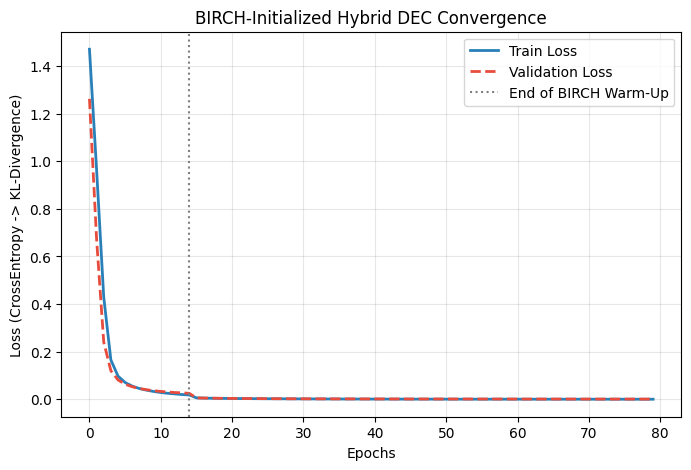


[DEC Complete] Extracted 8018 self-supervised asset labels.


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Deep Embedding Clustering on: {device.type.upper()}")

# ---------------------------------------------------------
# Step 1: Prepare Data (Using PCA + BIRCH Labels!)
# ---------------------------------------------------------
# Swapped to X_pca and clusters_birch_pca
X_train_nn, X_val_nn, y_train_pseudo, y_val_pseudo = train_test_split(
    X_pca, clusters_birch_pca, test_size=0.2, random_state=42, stratify=clusters_birch_pca
)

X_train_t = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_t = torch.tensor(y_train_pseudo, dtype=torch.long) 
X_val_t = torch.tensor(X_val_nn, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_pseudo, dtype=torch.long).to(device) 

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ---------------------------------------------------------
# Step 2: The DEC Target Distribution Function
# ---------------------------------------------------------
def get_target_distribution(q):
    # Added 1e-10 to prevent division by zero
    weight = q**2 / (q.sum(0) + 1e-10) 
    return (weight.t() / (weight.sum(1) + 1e-10)).t()

# ---------------------------------------------------------
# Step 3: Architecture & Initialization
# ---------------------------------------------------------
class ClusteringNN(nn.Module):
    def __init__(self, input_dim, n_clusters):
        super(ClusteringNN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, n_clusters)
        )

    def forward(self, x):
        return self.encoder(x)
    
# Swapped input_dim to X_pca
model = ClusteringNN(input_dim=X_pca.shape[1], n_clusters=5).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
ce_loss_fn = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# Step 4: Hybrid Training Loop (Warm-up + DEC)
# ---------------------------------------------------------
epochs = 80
train_losses = []
val_losses = []

print(f"Training Hybrid DEC (BIRCH Base): 15 Epochs CE Warm-Up -> 65 Epochs KL Self-Supervised...")

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    
    for batch_x, batch_y in train_loader: 
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        logits = model(batch_x)
        q = torch.softmax(logits, dim=1)
        
        # --- THE HYBRID SWITCH ---
        if epoch < 15:
            # WARM-UP: Learn BIRCH's highly accurate hard boundaries
            loss = ce_loss_fn(logits, batch_y)
        else:
            # DEC REFINEMENT: Soften the boundaries for probabilistic uncertainty
            p = get_target_distribution(q).detach()
            loss = F.kl_div((q + 1e-10).log(), p, reduction='batchmean')
        
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_q = torch.softmax(val_logits, dim=1)
        
        if epoch < 15:
            val_loss = ce_loss_fn(val_logits, y_val_t)
        else:
            val_p = get_target_distribution(val_q).detach()
            val_loss = F.kl_div((val_q + 1e-10).log(), val_p, reduction='batchmean')
            
        val_losses.append(val_loss.item())
        
    if (epoch + 1) % 10 == 0:
        phase = "Warm-Up (CE)" if epoch < 15 else "Self-Supervised (KL)"
        print(f"Epoch [{epoch+1}/{epochs}] | {phase} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss.item():.4f}")

# ---------------------------------------------------------
# Step 5: Plotting the Learning Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='#2980b9', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='#e74c3c', linewidth=2, linestyle='--')
plt.axvline(x=14, color='gray', linestyle=':', label='End of BIRCH Warm-Up')
plt.title("BIRCH-Initialized Hybrid DEC Convergence")
plt.xlabel("Epochs")
plt.ylabel("Loss (CrossEntropy -> KL-Divergence)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Step 6: Final Refined Classification
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    all_X_t = torch.tensor(X_pca, dtype=torch.float32).to(device)
    logits = model(all_X_t)
    soft_outputs = torch.softmax(logits, dim=1)
    
    dec_clusters = torch.argmax(soft_outputs, dim=1).cpu().numpy()
    dec_confidences = torch.max(soft_outputs, dim=1).values.cpu().numpy()

print(f"\n[DEC Complete] Extracted {len(dec_clusters)} self-supervised asset labels.")

--- Sentinel-CPS: Final Methodology Comparison ---
Method 1 [BIRCH + PCA Baseline] -> ARI: 0.4938 | NMI: 0.6093 | Homo: 0.6200
Method 2 [Hybrid DEC Refinement]-> ARI: 0.5136 | NMI: 0.6344 | Homo: 0.6475


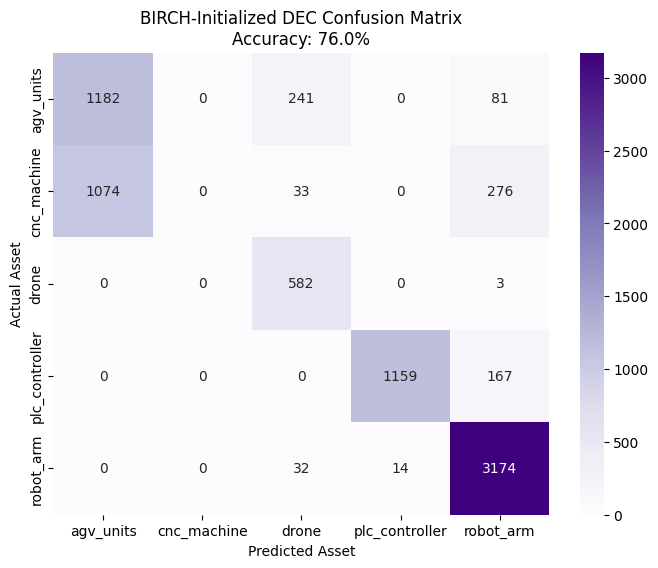


[Cyber-Audit] Hybrid DEC restored uncertainty metrics, flagging 3 images with <70% certainty for manual review.


In [20]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, confusion_matrix
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate the metrics for the BIRCH->DEC output
dec_ari = adjusted_rand_score(true_labels, dec_clusters)
dec_nmi = normalized_mutual_info_score(true_labels, dec_clusters)
dec_homo = homogeneity_score(true_labels, dec_clusters)

# 2. Print the side-by-side comparison
print("--- Sentinel-CPS: Final Methodology Comparison ---")
# Using the BIRCH baseline you provided earlier
print(f"Method 1 [BIRCH + PCA Baseline] -> ARI: 0.4938 | NMI: 0.6093 | Homo: 0.6200")
print(f"Method 2 [Hybrid DEC Refinement]-> ARI: {dec_ari:.4f} | NMI: {dec_nmi:.4f} | Homo: {dec_homo:.4f}")

# 3. Map the DEC clusters to strings for the Confusion Matrix
pred_labels_dec = map_clusters_to_truth(true_labels, dec_clusters)

# 4. Plot the Deep Clustering Confusion Matrix
plt.figure(figsize=(8, 6))
cm_dec = confusion_matrix(true_labels, pred_labels_dec, labels=unique_classes)
sns.heatmap(cm_dec, annot=True, fmt='d', cmap='Purples', 
            xticklabels=unique_classes, yticklabels=unique_classes)

dec_accuracy = np.mean(true_labels == pred_labels_dec) * 100
plt.title(f'BIRCH-Initialized DEC Confusion Matrix\nAccuracy: {dec_accuracy:.1f}%')
plt.ylabel('Actual Asset')
plt.xlabel('Predicted Asset')
plt.show()

# 5. The Cyber-Audit (Uncertainty)
low_conf_mask_dec = dec_confidences < 0.70
print(f"\n[Cyber-Audit] Hybrid DEC restored uncertainty metrics, flagging {np.sum(low_conf_mask_dec)} images with <70% certainty for manual review.")

In [ ]:
# inference_all.py

import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from collections import Counter

SL_MODELS  = ["rf_model.pkl",    "svm_model.pkl"]
USL_MODELS = [("gmm", "gmm_model.pkl"), ("dec", "dec_model.pt")]
RL_MODELS  = ["q_brain.json",    "sarsa_brain.json"]

def parse_label(label):
    if label.startswith("robotic_arm"):
        return "robotic_arm", label[12:]
    elif label.startswith("agv_unit"):
        return "agv_unit", label[9:]
    else:
        parts = label.split("_")
        return parts[0], "_".join(parts[1:])

def evaluate_levels(gt, air, override, sl_ans, sl_conf, usl_ans, usl_conf):
    gt_base, _          = parse_label(gt)
    sl_base, sl_attrs   = parse_label(sl_ans)
    l1 = (sl_base == gt_base) and (sl_conf > 0.98)
    fly_ok      = ("fly" in sl_attrs) if air else ("non_fly" in sl_attrs or "fly" not in sl_attrs)
    override_ok = ("override" in sl_attrs) if override else ("non_override" in sl_attrs or "override" not in sl_attrs)
    l2 = fly_ok and override_ok
    l3 = (usl_ans == gt) and (usl_conf > 0.95)
    return l1, l2, l3, int(l1) + int(l2) + int(l3)

def aggregate_usl_result(result, class_names):
    majority_cluster = Counter(result.predictions).most_common(1)[0][0]
    majority_mask    = result.predictions == majority_cluster
    return class_names[majority_cluster], float(np.mean(result.confidences[majority_mask]))

def combo_tag(sl_file, usl_name, rl_file):
    sl = sl_file.replace(".pkl", "").replace(".pt", "")
    rl = rl_file.replace(".json", "")
    return f"{sl}__{usl_name}__{rl}"


Path("RESULTS").mkdir(exist_ok=True)
spawner = DataSpawner(csv_path="DATA/SENSOR_STATS.csv", image_dir="DATA/DATASET")
map_gen = MapGenerator(seed=SEED)
map_gen.generate_map()
all_df1_rows = []
df2_rows = []
total_pipeline_time = 0.0
combo_count = 0

# Grid Search
for sl_file, (usl_name, usl_file), rl_file in product(SL_MODELS, USL_MODELS, RL_MODELS):
    combo_count += 1
    tag = combo_tag(sl_file, usl_name, rl_file)
    sl_engine  = SLInference(model_dir="MODELS",  model_file=sl_file)
    usl_engine = USLInference(model_dir="MODELS", pipeline_name=usl_name, seed=SEED)
    rl_engine  = RLInference(model_dir="MODELS",  qtable_file=rl_file)

    combo_total_time = 0.0
    level_cleared_sum = 0

    # Evaluating Both Models
    for loc_id in range(10):
        target_class, sampled_rows_df, images_paths, gt_air, gt_override = spawner.get_payload(loc_id)
        sl_ans, sl_conf, sl_time = sl_engine.run(sampled_rows_df.to_dict('records'))
        usl_result = usl_engine.run(images_paths)
        usl_ans, usl_conf = aggregate_usl_result(usl_result, spawner.classes)
        usl_time = usl_result.elapsed_sec
        combo_total_time += sl_time + usl_time
        l1, l2, l3, lvl = evaluate_levels(
            target_class, gt_air, gt_override,
            sl_ans, sl_conf, usl_ans, usl_conf
        )
        level_cleared_sum += lvl

        # For master DF1
        all_df1_rows.append({
            "Location_ID": loc_id,
            "Ground_Truth": target_class, "Airborne_(GT)": gt_air, "Override_(GT)": gt_override,
            "SL_Answer": sl_ans, "SL_Conf": sl_conf,
            "USL_Answer": usl_ans, "USL_Conf": usl_conf,
            "L1_Cleared": l1, "L2_Cleared": l2, "L3_Cleared": l3, "Level_Cleared": lvl,
            "USL_Model": usl_file, "SL_Model": sl_file, "RL_Model": rl_file
        })

    # RL Navigation
    gif_path = f"RESULTS/rl_animation__{tag}.gif"
    path, reward, rl_time = rl_engine.run(map_gen, animate=True, gif_path=gif_path)

    combo_total_time += rl_time
    total_pipeline_time += combo_total_time

    # For master DF2
    df2_rows.append({
        "SL_Model": sl_file,
        "USL_Model": usl_file,
        "RL_Model": rl_file,
        "Points_Level_Cleared": level_cleared_sum,
        "Total_Rewards_Collected": round(reward, 4),
        "Time_Taken_RL": round(rl_time, 4),
        "Total_Time": round(combo_total_time, 4)
    })

# Saving
df1 = pd.DataFrame(all_df1_rows)
df1_cols = [
    "Location_ID", "Ground_Truth", "Airborne_(GT)", "Override_(GT)", 
    "SL_Answer", "SL_Conf", "USL_Answer", "USL_Conf", 
    "L1_Cleared", "L2_Cleared", "L3_Cleared", "Level_Cleared", 
    "USL_Model", "SL_Model", "RL_Model"
]
df1 = df1[df1_cols]
df1.to_csv("RESULTS/df1_all.csv", index=False)
df2 = pd.DataFrame(df2_rows)
df2_cols = [
    "SL_Model", "USL_Model", "RL_Model", 
    "Points_Level_Cleared", "Total_Rewards_Collected", 
    "Time_Taken_RL", "Total_Time"
]
df2 = df2[df2_cols]
df2.to_csv("RESULTS/df2_all_combinations.csv", index=False)